In [1]:
# Install necessary libraries
%pip install torch torchvision torchaudio pandas scikit-learn

# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlparse, urlunparse
import uuid

Note: you may need to restart the kernel to use updated packages.


## Load Datasets

In [2]:
df = pd.read_excel("香水数据.xlsx")
interactions = pd.read_excel("香水评论数据.xlsx")

In [3]:
df

,香水链接,香水名称,香水品牌,调香师,属性,香调,前调,中调,后调
0,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']"
1,/xiangshui/228297-yafang-avon-today.html,"雅芳 今日女士 Avon Today, 2004",雅芳,Olivier Cresp,女香,木质花香调,"['小苍兰', '仙人掌', '千金子藤']","['晚香玉', '橙花', '木槿', '鹤望兰', '醉鱼草']","['麝香', '水', '木质香', '雪松', '玫瑰']"
2,/xiangshui/363757-yafang-yaoyuan-avon-far-away...,"雅芳 遥远 Avon Far Away, 1994",雅芳,NaN,女香,花香东方调,"['椰子', '依兰', '桃子', '卡罗花', '橙子']","['茉莉', '栀子花', '紫罗兰', '小苍兰', '桂花', '玫瑰']","['香草', '檀香木', '琥珀', '麝香']"
3,/xiangshui/383970-yafang-avon-tomorrow.html,"雅芳 明日女士 Avon Tomorrow, 2005",雅芳,Olivier Cresp,女香,花香东方调,"['桃子', '金盏花', '胡椒', '广藿香', '树莓']","['橙花', '紫罗兰']","['檀香木', '琥珀', '巴西红木', '麝香']"
4,/xiangshui/309442-women-of-earth.html,"雅芳 地球女人 Avon Women of Earth, 1998",雅芳,Calice Becker,女香,果香花香调,"['无花果', '橙子', '香柠檬']","['苹果花', '月桂花', '茉莉']","['桃子', '麝香', '檀香木', '琥珀', '香草']"
...,...,...,...,...,...,...,...,...,...
61871,/xiangshui/912811-atkinsons-sport-red-energy.html,"阿特金森 跃动红色能量版 Atkinsons Sport Red Energy, 2010",NaN,NaN,中性香,果香花香调,"['蜜橘', '橙子', '香柠檬']","['茉莉', '铃兰', '肉桂']","['香草', '零陵香豆', '广藿香', '檀香木']"
61872,/xiangshui/359864-atkinsons-indolence.html,"阿特金森 怠惰 Atkinsons Indolence, 1970",NaN,NaN,女香,NaN,[],[],[]
61873,/xiangshui/676294-atkinsons-sport-black-impact...,"阿特金森 跃动黑色版 Atkinsons Sport Black Impact, 2010",NaN,NaN,中性香,西普调,"['绿叶', '香柠檬', '葡萄柚']","['紫罗兰', '栀子花', '鼠尾草']","['檀香木', '麝香', '香根草']"
61874,/xiangshui/411087-atejinsen-atkinsons-spirit-a...,阿特金森 非洲之魂哈瓦诱惑版 Atkinsons Spirit of Africa Hawa...,NaN,NaN,女香,花香东方调,[],[],[]


In [4]:
interactions

,香水链接,评论,用户ID,用户名,评分,评论时间,点赞数,回复数
0,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,刚毕业的时候用过这个小黑裙身体乳，但是总觉得这个牌子不上档次用出去有点没面子，后来用过很多香...,58645559,玉面书生,0.5,2015-11-21,2.0,66.0
1,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,喜欢这款香不是因为香水本身更多的是情怀在我还是屁大点小丫头的时候留齐耳短发黑衣黑裤黑鞋子对一...,50659948,今天被蚊子咬了,0.5,2018-11-20,1.0,55.0
2,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,这款香水只有7.6分吗？我不服。香水时代只要不是太雷的香水一般都有8分，这款如此经典的小黑裙...,29445178,十二月第一天逛公园,0.5,2021-02-15,2.0,25.0
3,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,挺成熟的香味，前调一些姜的辛辣味道，中调开始最明显的是茉莉栀子花的味，没有吲哚感，是加工过后...,53182016,圆乎乎的小肉球,4.0,2024-09-29,NaN,4.0
4,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,入门的香，就是雅芳的小黑裙。当初还是十五六岁的少女（哦哈哈我现在也才二十），觉得会太老了，个...,56628719,森林里的老歌,4.0,2016-02-16,NaN,16.0
...,...,...,...,...,...,...,...,...
145167,/xiangshui/861241-atkinsons-24-old-bond-street...,这牌子香水闻着还可以，但是感觉扩香都不太灵的样纸，基本上三个小时后我就闻不到了。一般我是没有...,36295270,苏大胃,4.0,2022-10-30,NaN,NaN
145168,/xiangshui/861241-atkinsons-24-old-bond-street...,闻的极致版和原版的。这个是极致版。但是我也没有闻出来两者的差别。以下是原版洗完澡出来最舒适的...,30299352,云纠。,4.0,2019-05-01,NaN,NaN
145169,/xiangshui/202686-atkinsons-california-poppy-n...,刚喷出来的时候水生气息和胡椒的辛辣味还是挺重的，如果是喷在试香纸上过一段时间能闻到一丢丢香根...,52709890,BeyondRose,3.0,2023-06-21,NaN,NaN
145170,/xiangshui/407575-the-joss-flower.html,直冲脑门的甜，有点化工感的桃子味，加上豆蔻和焚香，特别齁。本来我还挺喜甜的，一直觉得到黑鸦片...,52709890,BeyondRose,2.0,2023-07-17,NaN,NaN


In [5]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145172 entries, 0 to 145171
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   香水链接    145172 non-null  object 
 1   评论      145172 non-null  object 
 2   用户ID    145172 non-null  int64  
 3   用户名     145054 non-null  object 
 4   评分      145172 non-null  float64
 5   评论时间    145172 non-null  object 
 6   点赞数     23615 non-null   float64
 7   回复数     86441 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 8.9+ MB


# Data Processing and Cleaning

### Finding the intersections between both datasets based on the 香水链接

In [6]:
intersection = pd.merge(df, interactions, on='香水链接', how='inner')

In [7]:
intersection

,香水链接,香水名称,香水品牌,调香师,属性,香调,前调,中调,后调,评论,用户ID,用户名,评分,评论时间,点赞数,回复数
0,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",刚毕业的时候用过这个小黑裙身体乳，但是总觉得这个牌子不上档次用出去有点没面子，后来用过很多香...,58645559,玉面书生,0.5,2015-11-21,2.0,66.0
1,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",喜欢这款香不是因为香水本身更多的是情怀在我还是屁大点小丫头的时候留齐耳短发黑衣黑裤黑鞋子对一...,50659948,今天被蚊子咬了,0.5,2018-11-20,1.0,55.0
2,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",这款香水只有7.6分吗？我不服。香水时代只要不是太雷的香水一般都有8分，这款如此经典的小黑裙...,29445178,十二月第一天逛公园,0.5,2021-02-15,2.0,25.0
3,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",挺成熟的香味，前调一些姜的辛辣味道，中调开始最明显的是茉莉栀子花的味，没有吲哚感，是加工过后...,53182016,圆乎乎的小肉球,4.0,2024-09-29,NaN,4.0
4,/xiangshui/746294-yafang-xiaoheiqun-avon-littl...,"雅芳 小黑裙 Avon Little Black Dress, 2001",雅芳,Barbara Zoebelein,女香,东方调,"['仙客来', '芫荽', '生姜', '杏树花', '忍冬']","['依兰', '茉莉', '栀子花', '牡丹', '曼陀罗']","['李子', '檀香木', '麝香', '零陵香豆', '木质香']",入门的香，就是雅芳的小黑裙。当初还是十五六岁的少女（哦哈哈我现在也才二十），觉得会太老了，个...,56628719,森林里的老歌,4.0,2016-02-16,NaN,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145167,/xiangshui/861241-atkinsons-24-old-bond-street...,阿特金森 二十四号老邦德街典雅古龙水限量版 Atkinsons 24 Old Bond St...,NaN,Christine Nagel,中性香,芳香木质调,"['杜松', '小豆蔻']","['威士忌', '玫瑰']","['茶叶', '龙涎香', '雪松', '麝香']",这牌子香水闻着还可以，但是感觉扩香都不太灵的样纸，基本上三个小时后我就闻不到了。一般我是没有...,36295270,苏大胃,4.0,2022-10-30,NaN,NaN
145168,/xiangshui/861241-atkinsons-24-old-bond-street...,阿特金森 二十四号老邦德街典雅古龙水限量版 Atkinsons 24 Old Bond St...,NaN,Christine Nagel,中性香,芳香木质调,"['杜松', '小豆蔻']","['威士忌', '玫瑰']","['茶叶', '龙涎香', '雪松', '麝香']",闻的极致版和原版的。这个是极致版。但是我也没有闻出来两者的差别。以下是原版洗完澡出来最舒适的...,30299352,云纠。,4.0,2019-05-01,NaN,NaN
145169,/xiangshui/202686-atkinsons-california-poppy-n...,"阿特金森 加州罂粟新版本 Atkinsons California Poppy (new),...",NaN,NaN,女香,木质花香调,"['粉红胡椒', '香柠檬', '茉莉', '柠檬']","['西瓜酮', '罂粟花', '橙花']","['麝香', '雪松', '焚香']",刚喷出来的时候水生气息和胡椒的辛辣味还是挺重的，如果是喷在试香纸上过一段时间能闻到一丢丢香根...,52709890,BeyondRose,3.0,2023-06-21,NaN,NaN
145170,/xiangshui/407575-the-joss-flower.html,"阿特金森 芳香鲜花 Atkinsons The Joss Flower, 2019",NaN,NaN,中性香,花香东方调,"['焚香', '肉豆蔻', '粉红胡椒']","['栀子花', '依兰', '桃子', '鸢尾花']","['檀香木', '琥珀', '广藿香']",直冲脑门的甜，有点化工感的桃子味，加上豆蔻和焚香，特别齁。本来我还挺喜甜的，一直觉得到黑鸦片...,52709890,BeyondRose,2.0,2023-07-17,NaN,NaN


### Giving uuid to the 香水链接 as 香水ID

In [8]:
def normalize_perfume_url(url):
    """Normalize perfume URLs for consistent UUID generation"""
    # Parse URL components
    parsed = urlparse(url)
    
    # Standardize path (remove duplicate slashes, lowercase)
    path = parsed.path.lower().replace('//', '/').rstrip('/')
    
    # Remove common tracking parameters if needed
    query = ''
    if '?' in url:
        # Keep only specific parameters if important for uniqueness
        # For most perfume URLs, you might ignore all query parameters
        pass
    
    # Reconstruct normalized URL
    normalized = urlunparse((
        parsed.scheme if parsed.scheme else 'https',  # default to https
        parsed.netloc.lower(),
        path,
        parsed.params,
        query,
        ''  # remove fragment
    ))
    
    return normalized

def url_to_perfume_id(url):
    """Generate UUID5 perfume ID from normalized URL"""
    normalized = normalize_perfume_url(url)
    return str(uuid.uuid5(uuid.NAMESPACE_URL, normalized))

In [9]:
intersection['香水ID'] = intersection['香水链接'].apply(url_to_perfume_id)

In [10]:
intersection["香水ID"].nunique()
# 数据库里有17445个unique香水

17445

In [11]:
intersection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145172 entries, 0 to 145171
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   香水链接    145172 non-null  object 
 1   香水名称    145172 non-null  object 
 2   香水品牌    56485 non-null   object 
 3   调香师     88785 non-null   object 
 4   属性      144840 non-null  object 
 5   香调      137414 non-null  object 
 6   前调      145172 non-null  object 
 7   中调      145172 non-null  object 
 8   后调      145172 non-null  object 
 9   评论      145172 non-null  object 
 10  用户ID    145172 non-null  int64  
 11  用户名     145054 non-null  object 
 12  评分      145172 non-null  float64
 13  评论时间    145172 non-null  object 
 14  点赞数     23615 non-null   float64
 15  回复数     86441 non-null   float64
 16  香水ID    145172 non-null  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 18.8+ MB


### Remove columns - 只需要perfume_id, 用户id, 评分

In [12]:
cols_to_keep = ["香水ID", "用户ID", "评分"]
intersection_df = intersection[cols_to_keep]

In [13]:
intersection_df.info()
# check that data is complete with no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145172 entries, 0 to 145171
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   香水ID    145172 non-null  object 
 1   用户ID    145172 non-null  int64  
 2   评分      145172 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.3+ MB


# Label Encoding

In [14]:
# encode user using LabelEncoder
user_encoder = LabelEncoder()
intersection_df['user_id'] = user_encoder.fit_transform(intersection_df["用户ID"])

# encode perfumes using LabelEncoder
perfume_encoder = LabelEncoder()
intersection_df['perfume_id'] = perfume_encoder.fit_transform(intersection_df["香水ID"])


/var/folders/h3/h9v20b_x3hj8p96jf0r_r65w0000gn/T/ipykernel_55489/3867567346.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intersection_df['user_id'] = user_encoder.fit_transform(intersection_df["用户ID"])
/var/folders/h3/h9v20b_x3hj8p96jf0r_r65w0000gn/T/ipykernel_55489/3867567346.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intersection_df['perfume_id'] = perfume_encoder.fit_transform(intersection_df["香水ID"])


In [15]:
intersection_df

,香水ID,用户ID,评分,user_id,perfume_id
0,cfcbc964-746c-5028-80c8-f401fad28a0f,58645559,0.5,26959,14179
1,cfcbc964-746c-5028-80c8-f401fad28a0f,50659948,0.5,22800,14179
2,cfcbc964-746c-5028-80c8-f401fad28a0f,29445178,0.5,11890,14179
3,cfcbc964-746c-5028-80c8-f401fad28a0f,53182016,4.0,24106,14179
4,cfcbc964-746c-5028-80c8-f401fad28a0f,56628719,4.0,25905,14179
...,...,...,...,...,...
145167,f38ddb32-227a-5b05-87a9-805ffece7a6e,36295270,4.0,15432,16605
145168,f38ddb32-227a-5b05-87a9-805ffece7a6e,30299352,4.0,12319,16605
145169,99a7fdcf-9d35-58a2-951a-91eb789514ed,52709890,3.0,23862,10433
145170,4ce440b4-30b0-5640-916a-cf991f9c4a7d,52709890,2.0,23862,5279


In [16]:
intersection_df["perfume_id"].nunique()


17445

In [17]:
intersection_df["user_id"].nunique()


31600

# Dataset Splitting

In [18]:
# splitting 70-30 for each user
train_data = []
test_data = []


for user_id, group in intersection_df.groupby('user_id'):

  if len(group) > 1:
    first_70 = round(group.shape[0]*0.7)
    train_data.append(group.iloc[:first_70, :])
    test_data.append(group.iloc[first_70:, :])


# Convert lists to DataFrames
train_data = pd.concat(train_data, ignore_index=True)
test_data = pd.concat(test_data, ignore_index=True)

In [19]:
print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (87011, 5)
Testing data shape: (39529, 5)


### Make sure that the test data exist in the training data

In [20]:
# Get unique users and items from the training data
train_users = set(train_data['user_id'].unique())
train_items = set(train_data['perfume_id'].unique())

# Filter the test set
filtered_test_data = test_data[
    test_data['user_id'].isin(train_users) & test_data['perfume_id'].isin(train_items)
]

## Create Dataloader

In [21]:
class InteractionsDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return {
            'user_id': torch.tensor(row['user_id'], dtype=torch.long),
            'perfume_id': torch.tensor(row['perfume_id'], dtype=torch.long),
            '评分': torch.tensor(row['评分'], dtype=torch.float),
        }

# Create DataLoader
batch_size = 512
train_dataset = InteractionsDataset(train_data)
test_dataset = InteractionsDataset(filtered_test_data)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# NeuMF Model

In [22]:
import torch
import torch.nn as nn

class NeuMF(nn.Module):
    def __init__(self, num_users, num_perfumes, embedding_dim):
        super(NeuMF, self).__init__()

        # GMF Components
        self.user_embeddings_gmf = nn.Embedding(num_users, embedding_dim)
        self.perfume_embeddings_gmf = nn.Embedding(num_perfumes, embedding_dim)

        # MLP Components
        self.user_embeddings_mlp = nn.Embedding(num_users, embedding_dim)
        self.perfume_embeddings_mlp = nn.Embedding(num_perfumes, embedding_dim)
        # MLP Hidden Layers
        self.fc1_mlp = nn.Linear(2 * embedding_dim, 128)
        self.fc2_mlp = nn.Linear(128, 64)

        # Final layers
        self.fc1_combined = nn.Linear(embedding_dim + 64, 128)
        self.fc2_combined = nn.Linear(128, 1)

    def forward(self, user_id, perfume_id):
        # GMF
        user_emb_gmf = self.user_embeddings_gmf(user_id)
        perfume_emb_gmf = self.perfume_embeddings_gmf(perfume_id)
        gmf_output = user_emb_gmf * perfume_emb_gmf  # Element-wise product

        # MLP
        user_emb_mlp = self.user_embeddings_mlp(user_id)
        perfume_emb_mlp = self.perfume_embeddings_gmf(perfume_id)
        mlp_input = torch.cat([user_emb_mlp, perfume_emb_mlp], dim=-1)
        mlp_output = torch.relu(self.fc1_mlp(mlp_input))
        mlp_output = torch.relu(self.fc2_mlp(mlp_output))

        # Combine GMF and MLP outputs
        combined_input = torch.cat([gmf_output, mlp_output], dim=-1)
        combined_output = torch.relu(self.fc1_combined(combined_input))
        combined_output = torch.relu(self.fc2_combined(combined_output)) * 4 + 1

        return combined_output.squeeze()


# Model Training

In [23]:
# Instantiate and train the model
embedding_dim = 32
num_users = len(user_encoder.classes_)
num_perfumes = len(perfume_encoder.classes_)

model = NeuMF(num_users, num_perfumes, embedding_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        user_id = batch['user_id']
        perfume_id = batch['perfume_id']
        评分 = batch['评分']

        optimizer.zero_grad()
        outputs = model(user_id, perfume_id)
        loss = criterion(outputs, 评分)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss / len(train_loader)}')

# Evaluation
model.eval()
with torch.no_grad():
    total_loss = 0
    for batch in test_loader:
        user_id = batch['user_id']
        perfume_id = batch['perfume_id']
        评分 = batch['评分']

        outputs = model(user_id, perfume_id)
        loss = criterion(outputs, 评分)

        total_loss += loss.item()

    print(f'Test Loss : {total_loss / len(test_loader)}')

Epoch 1/20, Loss: 2.166355212996988
Epoch 2/20, Loss: 2.008947534420911
Epoch 3/20, Loss: 1.9122542654766757
Epoch 4/20, Loss: 1.803834727231194
Epoch 5/20, Loss: 1.67878838707419
Epoch 6/20, Loss: 1.5375337088809293
Epoch 7/20, Loss: 1.3893400528851678
Epoch 8/20, Loss: 1.2406726381357978
Epoch 9/20, Loss: 1.088426914285211
Epoch 10/20, Loss: 0.9553827916874605
Epoch 11/20, Loss: 0.8329674471827114
Epoch 12/20, Loss: 0.7253652088782366
Epoch 13/20, Loss: 0.6357369410641053
Epoch 14/20, Loss: 0.5559843676931718
Epoch 15/20, Loss: 0.4870287521797068
Epoch 16/20, Loss: 0.4329774698790382
Epoch 17/20, Loss: 0.38161561559228335
Epoch 18/20, Loss: 0.34248436461476717
Epoch 19/20, Loss: 0.30651988264392405
Epoch 20/20, Loss: 0.27733213656088884
Test Loss : 2.952189074187982


# Model Evaluation and Performance (Test Set)

## Generate Predictions

In [24]:
def generate_predictions(model, data_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in data_loader:
            user_id = batch['user_id']
            perfume_id = batch['perfume_id']
            outputs = model(user_id, perfume_id)
            predictions.extend(zip(user_id.numpy(), perfume_id.numpy(), outputs.numpy().round(0)))
    return predictions

test_predictions = generate_predictions(model, test_loader)

## Compute Relevance Score

In [25]:
filtered_test_data

,香水ID,用户ID,评分,user_id,perfume_id
0,d0bdfe54-db05-561c-8287-235cd650cfe4,4,0.5,0,14247
1,500b5b97-40c2-592c-98bc-de6696598449,4,0.5,0,5506
2,868e008c-ca96-590f-9feb-065b40a0369c,4,0.5,0,9082
3,6a4c7b84-be6d-5ee8-a7e7-e4685cb5971c,4,0.5,0,7229
4,739244b3-dd7e-5c31-939d-a65755d31f27,4,0.5,0,7817
...,...,...,...,...,...
39523,0675cf4f-3d0b-507f-a4d7-674c1285a224,67451591,4.0,31584,412
39524,9586660a-eec1-5ee0-9f57-5cabf23b3cbb,67451799,0.5,31585,10128
39526,843e0530-7cd6-56ff-a8f3-338598c9bda4,67469437,0.5,31592,8935
39527,9889c4c0-b6bb-5e97-a7c9-17fb61c4cccd,67472953,0.5,31594,10352


In [26]:
filtered_test_data['relevance'] = filtered_test_data['评分'].apply(lambda x: x if x > 0 else 0)

/var/folders/h3/h9v20b_x3hj8p96jf0r_r65w0000gn/T/ipykernel_55489/137674639.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_test_data['relevance'] = filtered_test_data['评分'].apply(lambda x: x if x > 0 else 0)


In [27]:
filtered_test_data

,香水ID,用户ID,评分,user_id,perfume_id,relevance
0,d0bdfe54-db05-561c-8287-235cd650cfe4,4,0.5,0,14247,0.5
1,500b5b97-40c2-592c-98bc-de6696598449,4,0.5,0,5506,0.5
2,868e008c-ca96-590f-9feb-065b40a0369c,4,0.5,0,9082,0.5
3,6a4c7b84-be6d-5ee8-a7e7-e4685cb5971c,4,0.5,0,7229,0.5
4,739244b3-dd7e-5c31-939d-a65755d31f27,4,0.5,0,7817,0.5
...,...,...,...,...,...,...
39523,0675cf4f-3d0b-507f-a4d7-674c1285a224,67451591,4.0,31584,412,4.0
39524,9586660a-eec1-5ee0-9f57-5cabf23b3cbb,67451799,0.5,31585,10128,0.5
39526,843e0530-7cd6-56ff-a8f3-338598c9bda4,67469437,0.5,31592,8935,0.5
39527,9889c4c0-b6bb-5e97-a7c9-17fb61c4cccd,67472953,0.5,31594,10352,0.5


## Compute NDCG

In [28]:
def dcg_at_k(relevance_scores, k):

    relevance_scores = np.asarray(relevance_scores)[:k]
    if relevance_scores.size:
        return np.sum((2**relevance_scores - 1) / np.log2(np.arange(2, relevance_scores.size + 2)))
    return 0.

def ndcg_at_k(relevance_scores, ideal_relevance_scores, k):
    dcg = dcg_at_k(relevance_scores, k)
    idcg = dcg_at_k(ideal_relevance_scores, k)
    if idcg == 0:
        return 0.
    return dcg / idcg


In [29]:
def compute_ndcg_for_user(user_id, predictions_df, k):
    user_predictions = predictions_df[predictions_df['user_id'] == user_id]
    user_predictions = user_predictions.sort_values(by='predicted_rating', ascending=False)

    # Get relevance scores in the predicted order
    relevance_scores = user_predictions['relevance'].tolist()

    # Ideal relevance scores
    ideal_relevance_scores = sorted(relevance_scores, reverse=True)

    return ndcg_at_k(relevance_scores, ideal_relevance_scores, k)


def compute_overall_ndcg(test_data_df, predictions, k):
    predictions_df = pd.DataFrame(predictions, columns=['user_id', 'perfume_id', 'predicted_rating'])
    merged_df = pd.merge(test_data_df[['user_id', 'perfume_id', 'relevance']], predictions_df, on=['user_id', 'perfume_id'], how='inner')

    if len(merged_df) < len(test_data_df):
        print(f"Warning: Some test data points ({len(test_data_df) - len(merged_df)}) could not be matched with predictions.")

    user_ids = merged_df['user_id'].unique()
    ndcg_scores = [compute_ndcg_for_user(user_id, merged_df, k) for user_id in user_ids]

    return np.mean(ndcg_scores)


In [30]:
compute_overall_ndcg(filtered_test_data, test_predictions, 10)

0.9231888527821931

## Compute Recall, MAP, HR

In [31]:
def compute_recall(user_id, merged_df, k):
    """
    Compute recall for a single user based on the top-K recommendations.
    """
    user_predictions = merged_df[merged_df['user_id'] == user_id].sort_values(by='predicted_rating', ascending=False).head(k)
    user_test_data = merged_df[merged_df['user_id'] == user_id].sort_values(by='relevance', ascending=False).head(k)
    
    relevant_items = set(user_test_data['perfume_id'])
    recommended_items = set(user_predictions['perfume_id'])
    
    hits = relevant_items.intersection(recommended_items)
    if len(relevant_items) == 0:
        return 0
    return len(hits) / len(relevant_items)

def average_precision_at_k(user_id, merged_df, k):
    user_predictions = merged_df[merged_df['user_id'] == user_id].sort_values(by='predicted_rating', ascending=False).head(k)
    user_test_data = merged_df[merged_df['user_id'] == user_id].sort_values(by='relevance', ascending=False).head(k)
    
    relevant_items = set(user_test_data['perfume_id'])
    recommended_items = user_predictions['perfume_id'].values  # Ranked list of recommendations

    ap_sum, hits = 0, 0
    for i, perfume_id in enumerate(recommended_items):
        if perfume_id in relevant_items:
            hits += 1
            ap_sum += hits / (i + 1)  # Precision at this rank
    
    return ap_sum / min(len(relevant_items), k) if relevant_items else 0

def compute_hit_rate(user_id, merged_df, k):
    """
    Compute hit rate for a single user based on the top-K recommendations.
    """
    # Get the top-K recommended items for the user
    user_predictions = merged_df[merged_df['user_id'] == user_id].sort_values(by='predicted_rating', ascending=False).head(k)
    # Get the relevant items for the user from the test data
    user_test_data = merged_df[merged_df['user_id'] == user_id].sort_values(by='relevance', ascending=False).head(k)
    
    relevant_items = set(user_test_data['perfume_id'])
    recommended_items = set(user_predictions['perfume_id'])
    
    # Check if there's at least one relevant item in the recommendations
    hit = int(len(relevant_items.intersection(recommended_items)) > 0)
    
    return hit


## Compute Overall Metrics

In [32]:
def compute_overall_metrics(test_data_df, predictions, k):
    """
    Compute overall recall, precision, F1 score, and hit rate by averaging over all users.
    """
    predictions_df = pd.DataFrame(predictions, columns=['user_id', 'perfume_id', 'predicted_rating'])
    merged_df = pd.merge(test_data_df[['user_id', 'perfume_id', 'relevance']], predictions_df, on=['user_id', 'perfume_id'], how='inner')

    user_ids = merged_df['user_id'].unique()
    
    recalls = []
    maps = []
    hit_rates = []
    
    for user_id in user_ids:
        recall = compute_recall(user_id, merged_df, k)
        map = average_precision_at_k(user_id, merged_df, k)
        hit_rate = compute_hit_rate(user_id, merged_df, k)
        
        recalls.append(recall)
        maps.append(map)
        hit_rates.append(hit_rate)
    
    mean_recall = np.mean(recalls)
    mean_maps = np.mean(maps)
    overall_hit_rate = np.mean(hit_rates)
    
    return mean_recall, mean_maps, overall_hit_rate


In [33]:
recalls = []
maps = []
ndcgs = []
hrs = []

for i in range(1, 11):
    recall, map, overall_hit_rate = compute_overall_metrics(filtered_test_data, test_predictions, i)
    ndcg = compute_overall_ndcg(filtered_test_data, test_predictions, i)
    recalls.append(recall)
    maps.append(map)
    ndcgs.append(ndcg)
    hrs.append(overall_hit_rate)
    print(f"K@{i} \n recall : {recall}, HR : {overall_hit_rate}, NDCG: {ndcg}, MAP : {map}")

K@1 
 recall : 0.8211310828583954, HR : 0.8211310828583954, NDCG: 0.8687250081846285, MAP : 0.8211310828583954
K@2 
 recall : 0.899912319158264, HR : 0.9442349846558526, NDCG: 0.8941514939168489, MAP : 0.8894563787812363
K@3 
 recall : 0.9323688440742366, HR : 0.9748355984217448, NDCG: 0.9051566514921865, MAP : 0.9217399775926739
K@4 
 recall : 0.9503288031565102, HR : 0.9850065760631302, NDCG: 0.9118874767800466, MAP : 0.940788031565103
K@5 
 recall : 0.9611573871109163, HR : 0.990267426567295, NDCG: 0.9156253091375206, MAP : 0.9528206926786498
K@6 
 recall : 0.9688148472892006, HR : 0.9943007452871547, NDCG: 0.9183123416118409, MAP : 0.9614372351307905
K@7 
 recall : 0.9736832216446419, HR : 0.9963174046470846, NDCG: 0.920045982516103, MAP : 0.9671480464171641
K@8 
 recall : 0.977148180622534, HR : 0.9979833406400701, NDCG: 0.9213546549465472, MAP : 0.9710203727479594
K@9 
 recall : 0.9800672219786642, HR : 0.9988601490574309, NDCG: 0.9223344999917228, MAP : 0.9743729544036427
K@10 


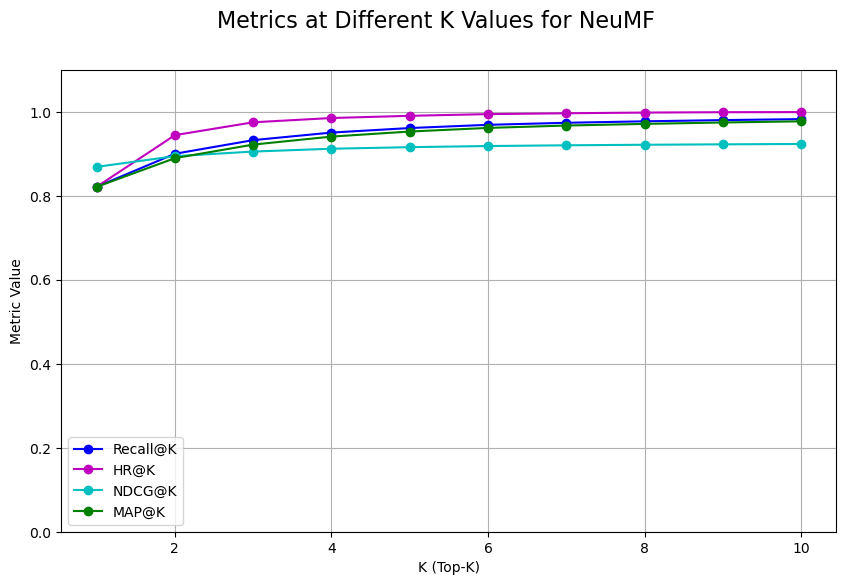

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Metrics at Different K Values for NeuMF", fontsize=16)

# Recall@K plot
ax.plot(range(1, len(recalls) + 1), recalls, marker='o', linestyle='-', color='b', label="Recall@K")

# HR@K plot
ax.plot(range(1, len(hrs) + 1), hrs, marker='o', linestyle='-', color='m', label="HR@K")

# NDCG@K plot
ax.plot(range(1, len(ndcgs) + 1), ndcgs, marker='o', linestyle='-', color='c', label="NDCG@K")

# MAP@K plot
ax.plot(range(1, len(maps) + 1), maps, marker='o', linestyle='-', color='g', label="MAP@K")


# Set labels and title
ax.set_xlabel("K (Top-K)")
ax.set_ylabel("Metric Value")
ax.set_ylim(0, 1.1)

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()


# Generation Predictions for 1 User

In [35]:
pd.set_option('display.max_colwidth', None)
def recommend_perfumes(user_id, k):
    model.eval()  # Set the model to evaluation mode

    # Get all perfumes the user has already interacted with
    encoded_user = user_encoder.transform([user_id])[0]
    interacted_perfumes = intersection_df[intersection_df['用户ID'] == encoded_user]['香水ID'].unique()

    # Filter out already interacted perfumes
    all_perfumes = intersection_df['perfume_id'].unique()
    candidate_perfumes = [perfume_id for perfume_id in all_perfumes if perfume_id not in interacted_perfumes]

    # Prepare a DataLoader for the user with candidate perfumes
    recommendations = []
    with torch.no_grad():
        for perfume_id in candidate_perfumes:
            # Create input tensor
            input_data = {
                'user_id': torch.tensor(encoded_user, dtype=torch.long).unsqueeze(0),
                'perfume_id': torch.tensor(perfume_id, dtype=torch.long).unsqueeze(0)
            }

            # Predict rating for the user-perfume pair
            predicted_rating = model(input_data['user_id'], input_data['perfume_id'])
            recommendations.append((perfume_id, round(predicted_rating.item(),1)))

    # Sort recommendations by predicted rating in descending order and take top K
    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)[:k]

    predicted_df = pd.DataFrame(recommendations, columns=['perfume_id', 'predicted_rating'])
    predicted_df['perfume_id'] = perfume_encoder.inverse_transform(predicted_df['perfume_id'])

    predicted_perfumes_df = pd.DataFrame(predicted_df.merge(
    intersection[['香水ID', '香水名称']].drop_duplicates(subset=['香水ID']),
    left_on='perfume_id',
    right_on='香水ID',
    how='left')["香水名称"])


    return predicted_perfumes_df

recommend_perfumes('29445178', 10)


,香水名称
0,"劳伦马佐 凶猛鸢尾 Laurent Mazzone Parfums Radikal Iris, 2018"
1,"兹法高 7种音调 Jivago 7 Notes, 1998"
2,"帝门特 银尖白毫茶 Demeter Fragrance Silvery Tip Pekoe Tea, 2015"
3,"鲁宾 辛巴达 Lubin Sinbad, 2019"
4,"罗马之香 雅柏 Profumum Roma Alba, 2004"
5,"伊夫黎雪 宁芙女神们的乐园 Yves Rocher Jardin des Nymphes, 2011"
6,"莱俪 白光男士 Lalique White, 2008"
7,"Maison Tahité 香草系列-海盐香草 Maison Tahité Sel-Vanille, 2020"
8,"心境 随性慷慨 State of Mind Spontaneous Generosity, 2017"
9,"维克多与罗夫 激情炸弹午夜版淡香精 Viktor&Rolf Spicebomb Night Vision Eau de Parfum, 2020"


# Sentiment analysis on the comments

In [36]:
import re
import jieba
import jieba.analyse
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

class AdvancedSentimentAnalyzer:

    def __init__(self):
        self.vader_analyzer =SentimentIntensityAnalyzer()
        self.positive_words =self._load_chinese_positive_words()
        self.negative_words =self._load_chinese_negative_words()
        self.degree_words =self._load_degree_modifiers()
        self.negation_words =self._load_negation_words()

        jieba.initialize()
        self.positive_threshold = 0.15
        self.negative_threshold = -0.15

    def _load_chinese_positive_words(self):
        return {
            '好', '棒', '赞', '爱', '喜欢', '满意', '开心', '高兴', '快乐', '舒服',
            '完美', '优秀', '出色', '杰出', '卓越', '精彩', '惊艳', '美妙', '绝佳', '一流',
            '香', '香甜', '好闻', '迷人', '优雅', '清新', '温柔', '甜美', '浪漫', '性感',
            '持久', '留香', '自然', '独特', '经典', '时尚', '精致', '奢华', '高级', '治愈',
            '温暖', '清香', '淡雅', '馥郁', '层次', '丰富', '平衡', '和谐', '细腻', '柔和',
            '推荐', '值得', '必买', '回购', '种草', '心水', '真香', '绝了', '爱了', '入坑'}

    def _load_chinese_negative_words(self):
        return {'差', '烂', '坏', '讨厌', '恶心', '失望', '难受', '痛苦', '糟糕', '可怕',
            '劣质', '廉价', '假', '次', '垃圾', '渣', '坑', '雷', '毒', '灾难',
            '难闻', '刺鼻', '呛人', '恶臭', '臭', '怪味', '化学味', '廉价感', '土气', '俗气',
            '短暂', '不持久', '淡', '无味', '单调', '普通', '一般', '平庸', '老气', '过时',
            '刺激', '过敏', '头疼', '头晕', '不适', '辣眼睛', '浓', '腻', '甜腻', '厚重',
            '不推荐', '不值', '后悔', '踩雷', '避雷', '慎入', '劝退', '翻车', '不行', '算了'
        }

    def _load_degree_modifiers(self):
        return {'非常': 2.0, '特别': 2.0, '超级': 2.5, '极其': 2.5, '十分': 1.8, '相当': 1.6,
            '太': 2.2, '最': 2.8, '超': 2.3, '巨': 2.4, '贼': 2.1, '死': 2.6,
            '很': 1.5, '挺': 1.3, '比较': 1.2, '还': 1.1, '颇': 1.4, '蛮': 1.3,
            '更': 1.3, '越来越': 1.4, '愈发': 1.5, '格外': 1.6, '尤其': 1.7,
            '有点': 0.9, '稍微': 0.8, '略': 0.8, '稍': 0.8, '些许': 0.7, '一点': 0.8,
            '还算': 1.0, '算是': 1.0, '基本': 0.9, '大致': 0.9, '总体': 1.0
        }

    def _load_negation_words(self):
        return {'不', '没', '无', '非', '未', '否', '别', '勿', '休', '莫',
            '毫无', '并非', '绝非', '决不', '从不', '永不', '从未', '绝不会'
        }

    def _preprocess_text(self, text):
        if not isinstance(text, str) or not text.strip():
            return ""

        text =text.lower().strip()
        text= re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
        text= re.sub(r'@\w+','',text)
        text=re.sub(r'#\w+','',text)
        text=re.sub(r'[!]{2,}','!', text)
        text= re.sub(r'[?]{2,}','?',text)
        text=re.sub(r'[.]{3,}','...',text)
        text= re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9\s.,!?;:()（）。，！？；：]','', text)
        text= re.sub(r'\s+',' ',text).strip()
        return text

    def _chinese_lexicon_analysis(self, text):
        if not text:
            return 0.0,0.0,0.5

        words = list(jieba.cut(text))
        positive_score=0.0
        negative_score=0.0
        total_sentiment_words=0
        i = 0
        while i < len(words):
            word = words[i]
            if word in self.positive_words or word in self.negative_words:
                base_score =1.0
                degree_multiplier =1.0
                negation_count =0

                for j in range(max(0,i-3), i):
                    prev_word = words[j]
                    if prev_word in self.degree_words:
                        degree_multiplier = max(degree_multiplier, self.degree_words[prev_word])
                    elif prev_word in self.negation_words:
                        negation_count += 1

                # Calculate final score
                final_score = base_score * degree_multiplier
                if word in self.positive_words:
                    if negation_count % 2== 0:
                        positive_score+=final_score
                    else:
                        negative_score +=final_score
                else:
                    if negation_count % 2== 0:
                        negative_score +=final_score
                    else:
                        positive_score+=final_score
                total_sentiment_words += 1

            i += 1

        if total_sentiment_words > 0:
            positive_score /=total_sentiment_words
            negative_score /=total_sentiment_words

        confidence = min(0.5+ (total_sentiment_words * 0.1) + (abs(positive_score - negative_score) * 0.3),0.95)

        return positive_score, negative_score, confidence

    def _vader_analysis(self, text):
        try:
            scores = self.vader_analyzer.polarity_scores(text)
            return scores['pos'], scores['neg'], scores['compound'], abs(scores['compound'])
        except:
            return 0.0, 0.0, 0.0, 0.5

    def _textblob_analysis(self, text):
        try:
            blob = TextBlob(text)
            polarity = blob.sentiment.polarity
            subjectivity = blob.sentiment.subjectivity

            if polarity > 0:
                pos_score = polarity
                neg_score = 0
            elif polarity < 0:
                pos_score = 0
                neg_score = abs(polarity)
            else:
                pos_score = neg_score = 0

            return pos_score, neg_score, polarity, subjectivity
        except:
            return 0.0, 0.0, 0.0, 0.5

    def analyze_sentiment(self, text):
        if not text or not text.strip():
            return 0.0, 0.0, "中性", 0.5, {}

        # Preprocess text
        processed_text = self._preprocess_text(text)

        # Method 1: Chinese lexicon analysis
        lex_pos, lex_neg, lex_conf = self._chinese_lexicon_analysis(processed_text)

        # Method 2: VADER analysis
        vader_pos, vader_neg, vader_compound, vader_conf = self._vader_analysis(processed_text)

        # Method 3: TextBlob analysis
        blob_pos, blob_neg, blob_polarity, blob_subjectivity = self._textblob_analysis(processed_text)

        # Ensemble scoring with weights (Chinese lexicon gets higher weight for Chinese text)
        chinese_char_ratio = len(re.findall(r'[\u4e00-\u9fa5]', text)) / max(len(text), 1)

        if chinese_char_ratio > 0.3:
            weights = [0.6, 0.25, 0.15]
        else:
            weights = [0.3, 0.4, 0.3]

        final_pos = (lex_pos * weights[0] + vader_pos * weights[1] + blob_pos * weights[2])
        final_neg = (lex_neg * weights[0] + vader_neg * weights[1] + blob_neg * weights[2])

        confidences = [lex_conf, vader_conf, blob_subjectivity]
        final_confidence = np.mean(confidences)

        net_sentiment = final_pos - final_neg

        if net_sentiment > self.positive_threshold and final_confidence > 0.6:
            sentiment_label = "正面"
        elif net_sentiment < self.negative_threshold and final_confidence > 0.6:
            sentiment_label = "负面"
        else:
            sentiment_label = "中性"

        detailed_scores = {
            'lexicon_pos':lex_pos,
            'lexicon_neg':lex_neg,
            'vader_compound':vader_compound,
            'textblob_polarity': blob_polarity,
            'chinese_ratio':chinese_char_ratio,
            'net_sentiment': net_sentiment
        }

        return final_pos,final_neg,sentiment_label,final_confidence,detailed_scores

print("Initializing Advanced Sentiment Analyzer...")
sentiment_analyzer = AdvancedSentimentAnalyzer()

def predict_label_advanced(text):
    try:
        pos_score,neg_score,label,confidence,details=sentiment_analyzer.analyze_sentiment(text)

        scaled_pos=pos_score * 10 - 5
        scaled_neg=neg_score * 10 - 5
        return pd.Series([scaled_pos, scaled_neg, label, confidence, details['net_sentiment']])
    except Exception as e:
        print(f"Sentiment analysis error: {e}")
        return pd.Series([0.0, 0.0, "中性", 0.5, 0.0])

print("Starting advanced sentiment analysis...")
interactions["评论"]= interactions["评论"].fillna("").astype(str)
sentiment_results= interactions["评论"].apply(predict_label_advanced)
interactions[["正向得分", "负向得分", "情绪标签", "置信度", "净情感分数"]] = sentiment_results
interactions["情感强度"]= abs(interactions["净情感分数"]) * interactions["置信度"]
interactions["情感极性"]= np.where(interactions["净情感分数"] > 0, 1, np.where(interactions["净情感分数"] < 0, -1, 0))

import os
os.makedirs("data", exist_ok=True)
interactions.to_excel("data/advanced_sentiment_analysis.xlsx", index=False)
print("Advanced sentiment analysis completed and saved.")

print("ADVANCED SENTIMENT ANALYSIS REPORT")
print(f"Dataset Overview:")
print(f"Total comments: {len(interactions):,}")
print(f"Non-empty comments: {len(interactions[interactions['评论'].str.len() > 0]):,}")
print(f"Average comment length: {interactions['评论'].str.len().mean():.1f} characters")

print(f"Sentiment Distribution:")
sentiment_counts = interactions['情绪标签'].value_counts()
for sentiment, count in sentiment_counts.items():
    percentage = count / len(interactions) * 100
    print(f"   {sentiment}: {count:,} ({percentage:.1f}%)")

print(f"Quality Metrics:")
print(f"Average confidence:{interactions['置信度'].mean():.3f}")
print(f"High confidence (>0.7):{(interactions['置信度']> 0.7).mean():.1%}")
print(f"Low confidence (<0.5):{(interactions['置信度']< 0.5).mean():.1%}")

print(f"Sentiment Intensity:")
print(f"Average intensity: {interactions['情感强度'].mean():.3f}")
print(f"Strong sentiment (>0.5): {(interactions['情感强度']> 0.5).mean():.1%}")

print(f"Rating-Sentiment Consistency:")
positive_high_rating= len(interactions[(interactions['情绪标签'] == '正面') & (interactions['评分'] >= 4)])
negative_low_rating= len(interactions[(interactions['情绪标签'] == '负面') & (interactions['评分'] <= 2)])
total_clear_cases= len(interactions[(interactions['评分']>= 4) | (interactions['评分'] <= 2)])

if total_clear_cases > 0:
    consistency= (positive_high_rating + negative_low_rating) / total_clear_cases
    print(f"Sentiment-rating consistency: {consistency:.1%}")
else:
    print(f"Sentiment-rating consistency: Cannot calculate")

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/h3/h9v20b_x3hj8p96jf0r_r65w0000gn/T/jieba.cache


Initializing Advanced Sentiment Analyzer...


Loading model cost 0.554 seconds.
Prefix dict has been built successfully.


Starting advanced sentiment analysis...
Advanced sentiment analysis completed and saved.
ADVANCED SENTIMENT ANALYSIS REPORT
Dataset Overview:
Total comments: 145,172
Non-empty comments: 145,172
Average comment length: 180.2 characters
Sentiment Distribution:
   中性: 144,133 (99.3%)
   正面: 968 (0.7%)
   负面: 71 (0.0%)
Quality Metrics:
Average confidence:0.295
High confidence (>0.7):0.4%
Low confidence (<0.5):98.9%
Sentiment Intensity:
Average intensity: 0.147
Strong sentiment (>0.5): 0.6%
Rating-Sentiment Consistency:
Sentiment-rating consistency: 0.4%


In [37]:
interactions[(interactions['情绪标签'] == '正面') & (interactions['评分'] >= 4)]['评论'].head()

408                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    【avon far away beyong the moon】超越无限：遥远的月光香水时代没有收录

In [38]:
interactions[(interactions['情绪标签'] == '负面') & (interactions['评分'] <= 2)]['评论'].head()

17221                                                                                                            从来没有闻过化工感这么强的玫瑰。而且CB的香支支都能把试纸泡软。失望到，把我气笑了……不如改名：CB, Perfumes Hate you.
17260                                      试闻了CB I hate perfume 的wild hunt（这玩意儿真的跟巫师三一个名字），前调是非常生冷的腐殖物以及潮湿菌类的味道，是真的森林气息。后调弱化之后只剩草木气息。中间香根草的气息稍强，但压不住草木的阴冷。评分5分因为它真的是我追求的味道，但穿出去需要莫大勇气了。
17438                           Despite all the awful comments about this fragrance ，I still wanna give it five stars.It reminds me of milk with almond flavor and maybe some cinnamon.
17445    对于我来说，CB I hate perfume的invisible monster是一次非常奇妙的体验。那时候恰好在读黄锦树的《雨》，是一段段在南洋胶林里氤氲纠缠的故事。那里总是下雨，雨水渗透进树干，蓬屋，土壤，甚至人与动物的每一寸皮肤。雨停之后，雾气从地下和树林深处就蒸腾起来，在这片茫茫的雾气中可以嗅到水，泥土，植物汁液，和一点点不具名的花香。
20162                                        一个字：甜。甜到炸了。像是很小的时候小卖部里五彩泡泡糖的味道，又甜又腻。闻了头晕。留香大概2到3个小时吧。没有前中后调变化（反正我没有闻出来）。喷完洗了好几遍手，真的挺怕别人闻见的，味道太廉价了。我受到了伤害.._:(´_`」 ∠):_ …唯一的一颗星送给我泡泡糖味道的童年。
Name: 评论, dtype: object

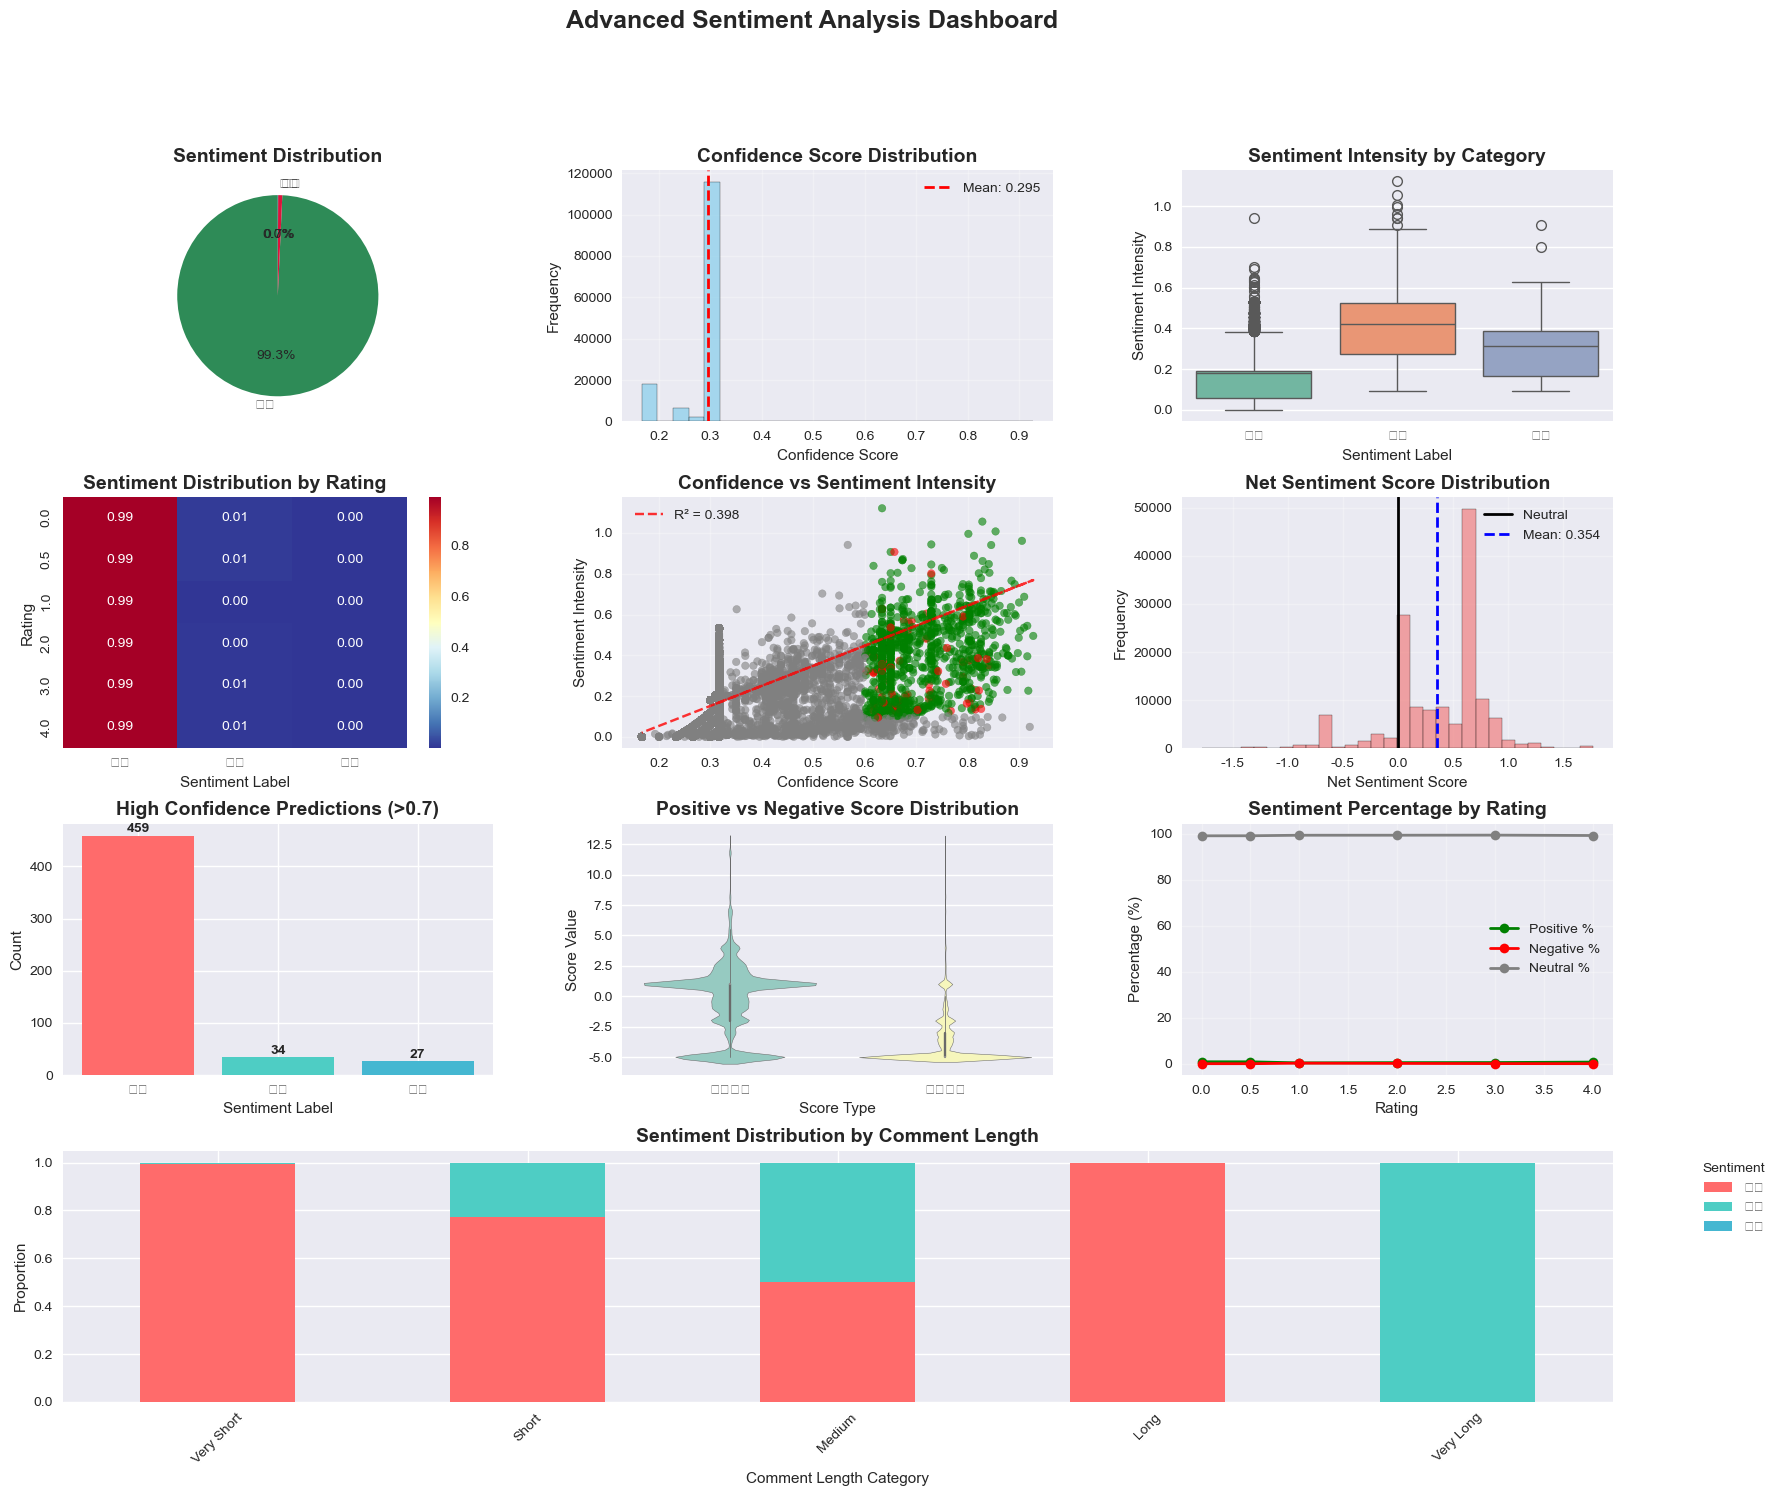

In [39]:
import seaborn as sns
from scipy import stats

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']  # For Chinese characters
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        pass

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Sentiment Distribution (Pie Chart)
ax1 = fig.add_subplot(gs[0, 0])
sentiment_counts = interactions['情绪标签'].value_counts()
colors = ['#2E8B57', '#DC143C', '#4682B4']  # Professional colors
wedges, texts, autotexts = ax1.pie(sentiment_counts.values, labels=sentiment_counts.index,
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')

# 2. Confidence Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(interactions['置信度'], bins=25, alpha=0.7, color='skyblue', edgecolor='black')
ax2.axvline(interactions['置信度'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {interactions["置信度"].mean():.3f}')
ax2.set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Sentiment Intensity by Category
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=interactions, x='情绪标签', y='情感强度', ax=ax3, palette='Set2')
ax3.set_title('Sentiment Intensity by Category', fontsize=14, fontweight='bold')
ax3.set_xlabel('Sentiment Label')
ax3.set_ylabel('Sentiment Intensity')

# 4. Sentiment vs Rating Heatmap
ax4 = fig.add_subplot(gs[1, 0])
rating_sentiment_crosstab = pd.crosstab(interactions['评分'], interactions['情绪标签'], normalize='index')
sns.heatmap(rating_sentiment_crosstab, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax4)
ax4.set_title('Sentiment Distribution by Rating', fontsize=14, fontweight='bold')
ax4.set_xlabel('Sentiment Label')
ax4.set_ylabel('Rating')

# 5. Confidence vs Intensity Scatter
ax5 = fig.add_subplot(gs[1, 1])
scatter = ax5.scatter(interactions['置信度'], interactions['情感强度'],
                     c=interactions['情绪标签'].map({'正面': 'green', '负面': 'red', '中性': 'gray'}),
                     alpha=0.6, s=30)
ax5.set_title('Confidence vs Sentiment Intensity', fontsize=14, fontweight='bold')
ax5.set_xlabel('Confidence Score')
ax5.set_ylabel('Sentiment Intensity')
ax5.grid(True, alpha=0.3)

# Add trend line
if len(interactions) > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(interactions['置信度'], interactions['情感强度'])
    line = slope * interactions['置信度'] + intercept
    ax5.plot(interactions['置信度'], line, 'r--', alpha=0.8,
             label=f'R² = {r_value**2:.3f}')
    ax5.legend()

# 6. Net Sentiment Distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(interactions['净情感分数'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
ax6.axvline(0, color='black', linestyle='-', linewidth=2, label='Neutral')
ax6.axvline(interactions['净情感分数'].mean(), color='blue', linestyle='--', linewidth=2,
           label=f'Mean: {interactions["净情感分数"].mean():.3f}')
ax6.set_title('Net Sentiment Score Distribution', fontsize=14, fontweight='bold')
ax6.set_xlabel('Net Sentiment Score')
ax6.set_ylabel('Frequency')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. High Confidence Sentiment Distribution
ax7 = fig.add_subplot(gs[2, 0])
high_conf_data= interactions[interactions['置信度'] > 0.7]
if len(high_conf_data) > 0:
    high_conf_counts= high_conf_data['情绪标签'].value_counts()
    bars = ax7.bar(high_conf_counts.index, high_conf_counts.values,
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax7.set_title('High Confidence Predictions (>0.7)', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Sentiment Label')
    ax7.set_ylabel('Count')
    for bar, value in zip(bars, high_conf_counts.values):
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(value), ha='center', va='bottom', fontweight='bold')
else:
    ax7.text(0.5, 0.5, 'No High Confidence\nPredictions', ha='center', va='center',
            transform=ax7.transAxes, fontsize=12)
    ax7.set_title('High Confidence Predictions (>0.7)', fontsize=14, fontweight='bold')

# 8. Sentiment Score Comparison (Violin Plot)
ax8 = fig.add_subplot(gs[2, 1])
score_data = pd.melt(interactions[['正向得分', '负向得分']],
                     var_name='Score Type', value_name='Score Value')
sns.violinplot(data=score_data, x='Score Type', y='Score Value', ax=ax8, palette='Set3')
ax8.set_title('Positive vs Negative Score Distribution', fontsize=14, fontweight='bold')
ax8.set_xlabel('Score Type')
ax8.set_ylabel('Score Value')

# 9. Rating vs Sentiment Consistency Analysis
ax9 = fig.add_subplot(gs[2, 2])
consistency_data = []
for rating in sorted(interactions['评分'].unique()):
    rating_data = interactions[interactions['评分'] == rating]
    pos_pct = (rating_data['情绪标签'] == '正面').mean() * 100
    neg_pct = (rating_data['情绪标签'] == '负面').mean() * 100
    neu_pct = (rating_data['情绪标签'] == '中性').mean() * 100
    consistency_data.append([rating, pos_pct, neg_pct, neu_pct])

consistency_df = pd.DataFrame(consistency_data, columns=['Rating', 'Positive %', 'Negative %', 'Neutral %'])
x = consistency_df['Rating']
ax9.plot(x, consistency_df['Positive %'], 'o-', color='green', label='Positive %', linewidth=2)
ax9.plot(x, consistency_df['Negative %'], 'o-', color='red', label='Negative %', linewidth=2)
ax9.plot(x, consistency_df['Neutral %'], 'o-', color='gray', label='Neutral %', linewidth=2)
ax9.set_title('Sentiment Percentage by Rating', fontsize=14, fontweight='bold')
ax9.set_xlabel('Rating')
ax9.set_ylabel('Percentage (%)')
ax9.legend()
ax9.grid(True, alpha=0.3)

# 10. Comment Length vs Sentiment Analysis
ax10 = fig.add_subplot(gs[3, :])
interactions['comment_length'] = interactions['评论'].str.len()
length_bins = pd.cut(interactions['comment_length'], bins=5, labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])
length_sentiment = pd.crosstab(length_bins, interactions['情绪标签'], normalize='index')
length_sentiment.plot(kind='bar', stacked=True, ax=ax10, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax10.set_title('Sentiment Distribution by Comment Length', fontsize=14, fontweight='bold')
ax10.set_xlabel('Comment Length Category')
ax10.set_ylabel('Proportion')
ax10.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
ax10.tick_params(axis='x', rotation=45)

plt.suptitle('Advanced Sentiment Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [40]:
# Additional Analysis: Method Comparison
sample_comments = interactions.sample(min(10, len(interactions)))['评论'].tolist()

print("\nSample Analysis (First 5 comments):")

for i, comment in enumerate(sample_comments[:5]):
    if len(comment.strip()) > 0:
        pos_score, neg_score, label, confidence, details = sentiment_analyzer.analyze_sentiment(comment)
        print(f"Comment {i+1}: {comment[:100]}{'...' if len(comment) > 100 else ''}")
        print(f" Final Label: {label} (Confidence: {confidence:.3f})")
        print(f" Scores - Positive: {pos_score:.3f}, Negative: {neg_score:.3f}")
        print(f" Chinese Ratio: {details['chinese_ratio']:.2f}")
        print(f" Net Sentiment: {details['net_sentiment']:.3f}")



Sample Analysis (First 5 comments):
Comment 1: 【甜而不腻】很经典的女香，刚喷出来的时候感觉味道挺浓烈，没想到5分钟以后就已经散得差不多了。果香加花香，甜腻又不失清新，还稍微带有一点水生调的感觉，刚开始闻有点点晕。总的来说玫瑰、柑橘和雪松味道比较明...
 Final Label: 中性 (Confidence: 0.317)
 Scores - Positive: 0.514, Negative: 0.171
 Chinese Ratio: 0.90
 Net Sentiment: 0.343
Comment 2: 上皮粉红椒与玫瑰的结合非常清新，像把鼻子贴在雨后湿玫瑰的里层花瓣。随后浆果的酸开始与玫瑰融合，变得异常酸甜，甚至会让人觉得有些腻。最后琥珀的香气把酸味进行了溶解，让整体香气重新回到了正轨。这款香还是挺...
 Final Label: 中性 (Confidence: 0.317)
 Scores - Positive: 0.540, Negative: 0.129
 Chinese Ratio: 0.92
 Net Sentiment: 0.411
Comment 3: 关于这款香水我见过它的香评中最为精准的当属辰雨的，虽然他对香水的评价多用繁复、磅礴、震撼人心之词，大多我并不以为然，唯有此款，他的感觉与文字，直指人心。这款香水用料极重而且繁杂，单看香调表已经让人咂舌...
 Final Label: 中性 (Confidence: 0.317)
 Scores - Positive: 1.140, Negative: 0.000
 Chinese Ratio: 0.89
 Net Sentiment: 1.140
Comment 4: 前调檀香木气味很明显，但不算扰人，中调感觉没调好，怪怪的工业塑料香精味，后调就是一股微甜的味，奶香木头味，跟马吉拉的壁炉火光不一样的感觉，马吉拉焦糖香对我来说很呛人，这款奶甜的香味属于是可以接受的范围...
 Final Label: 中性 (Confidence: 0.300)
 Scores - Positive: 0.600, Negative: 0.000
 Chinese Ratio: 0.92
 Net Sentiment: 0.600
Comment 5: 